In [1]:
import numpy as np
import pandas as pd

In [2]:
!pip install  prophet

In [3]:
from prophet import Prophet

In [4]:
df_data = pd.read_csv("https://raw.githubusercontent.com/jonasdieckmann/prophet_tutorial/main/passengers.csv")

df_data_train = df_data[df_data["Month"] < "2023-01"]
df_data_test = df_data[df_data["Month"] >= "2023-01"]

display(df_data_train)

,Month,Passengers
0,2012-01,112
1,2012-02,118
2,2012-03,132
3,2012-04,129
4,2012-05,121
...,...,...
127,2022-08,559
128,2022-09,463
129,2022-10,407
130,2022-11,362


In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

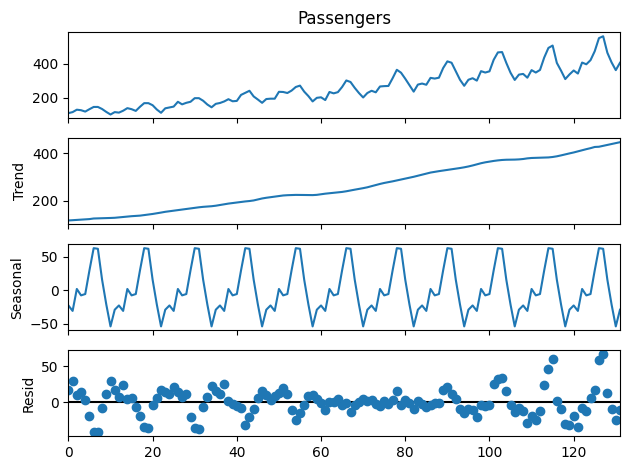

In [11]:
decompose = seasonal_decompose(df_data_train.Passengers ,model='additive',extrapolate_trend='freq', period=12)

decompose.plot().show()

In [12]:
df_train_prophet = df_data_train

# date variable needs to be named "ds" for prophet
df_train_prophet = df_train_prophet.rename(columns={"Month": "ds"})

# target variable needs to be named "y" for prophet
df_train_prophet = df_train_prophet.rename(columns={"Passengers": "y"})

In [13]:
model_prophet  = Prophet()
model_prophet.fit(df_train_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [14]:
df_future = model_prophet.make_future_dataframe(periods=12, freq='MS')
display(df_future)

,ds
0,2012-01-01
1,2012-02-01
2,2012-03-01
3,2012-04-01
4,2012-05-01
...,...
139,2023-08-01
140,2023-09-01
141,2023-10-01
142,2023-11-01


In [15]:
forecast_prophet = model_prophet.predict(df_future)
forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].round().tail()

,ds,yhat,yhat_lower,yhat_upper
139,2023-08-01,532.0,507.0,556.0
140,2023-09-01,484.0,459.0,507.0
141,2023-10-01,446.0,420.0,469.0
142,2023-11-01,416.0,391.0,442.0
143,2023-12-01,449.0,424.0,473.0


/tmp/ipykernel_647/219420338.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data_test['Month'] = pd.to_datetime(df_data_test['Month'])


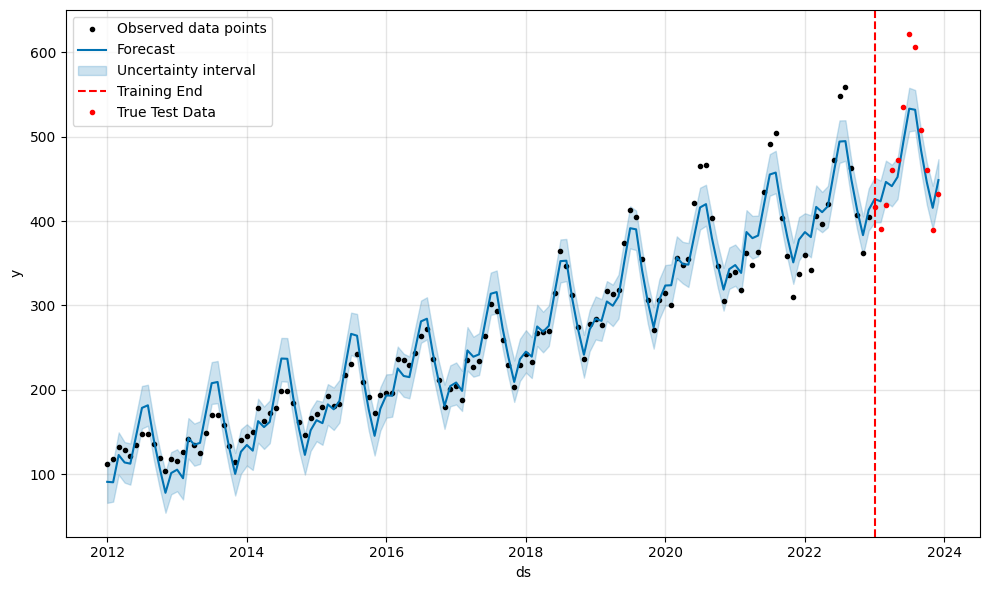

In [16]:
import matplotlib.pyplot as plt

# plot the time series
forecast_plot = model_prophet.plot(forecast_prophet)

# add a vertical line at the end of the training period
axes = forecast_plot.gca()
last_training_date = forecast_prophet['ds'].iloc[-12]
axes.axvline(x=last_training_date, color='red', linestyle='--', label='Training End')

# plot true test data for the period after the red line
df_data_test['Month'] = pd.to_datetime(df_data_test['Month'])
plt.plot(df_data_test['Month'], df_data_test['Passengers'],'ro', markersize=3, label='True Test Data')

# show the legend to distinguish between the lines
plt.legend()

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet

In [18]:
df = pd.read_csv('/content/Energy_consumption.csv')

In [19]:
df.head()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   object 
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   object 
 6   LightingUsage      1000 non-null   object 
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   object 
 9   Holiday            1000 non-null   object 
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 86.1+ KB


In [39]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [21]:
df.columns = df.columns.str.lower()

In [30]:
pd.to_datetime(df['timestamp'], format='%Y-%m-%d %H:%M:%S')

,timestamp
0,2022-01-01 00:00:00
1,2022-01-01 01:00:00
2,2022-01-01 02:00:00
3,2022-01-01 03:00:00
4,2022-01-01 04:00:00
...,...
995,2022-02-11 11:00:00
996,2022-02-11 12:00:00
997,2022-02-11 13:00:00
998,2022-02-11 14:00:00


In [32]:
df.describe()

,temperature,humidity,squarefootage,occupancy,renewableenergy,energyconsumption
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.982026,45.395412,1500.052488,4.581000,15.132813,77.055873
std,2.836850,8.518905,288.418873,2.865598,8.745917,8.144112
min,20.007565,30.015975,1000.512661,0.000000,0.006642,53.263278
25%,22.645070,38.297722,1247.108548,2.000000,7.628385,71.544690
50%,24.751637,45.972116,1507.967426,5.000000,15.072296,76.943696
75%,27.418174,52.420066,1740.340165,7.000000,22.884064,82.921742
max,29.998671,59.969085,1999.982252,9.000000,29.965327,99.201120


In [38]:
df.describe(include='object').T

,count,unique,top,freq
hvacusage,1000,2,Off,508
lightingusage,1000,2,Off,509
dayofweek,1000,7,Friday,164
holiday,1000,2,No,533


In [41]:
df['Month'] =df['timestamp'].dt.month
df['Day'] =df['timestamp'].dt.day
df['Hour'] =df['timestamp'].dt.hour
df['DayofWeek'] =df['timestamp'].dt.dayofweek
df['DayName'] =df['timestamp'].dt.day_name()

In [60]:
df['energyconsumption'].describe()

,energyconsumption
count,1000.000000
mean,77.055873
std,8.144112
min,53.263278
25%,71.544690
50%,76.943696
75%,82.921742
max,99.201120


In [67]:
df.groupby('DayName')['energyconsumption'].describe().reset_index().sort_values(by='mean',ascending=False)

,DayName,count,mean,std,min,25%,50%,75%,max
2,Saturday,144.0,78.869469,8.017480,56.519850,73.295949,78.535078,84.083558,98.843756
0,Friday,136.0,77.804169,8.238697,57.968914,71.853735,77.030873,83.344719,98.761754
5,Tuesday,144.0,77.384813,7.956658,56.849829,72.647039,77.399168,83.449279,95.570800
3,Sunday,144.0,76.881393,7.788872,59.608902,71.545677,76.018518,82.741753,96.827015
6,Wednesday,144.0,76.301242,8.277581,56.038163,70.594569,75.940012,81.838328,95.402960
4,Thursday,144.0,76.127288,7.646813,56.158206,70.729405,76.211706,81.272004,96.244796
1,Monday,144.0,76.064308,8.810008,53.263278,69.595493,76.849443,82.213416,99.201120


In [70]:
df.groupby('holiday')['energyconsumption'].describe().reset_index()

,holiday,count,mean,std,min,25%,50%,75%,max
0,No,533.0,76.624035,8.107184,53.263278,71.186230,76.308881,82.284392,99.201120
1,Yes,467.0,77.548741,8.166840,57.285639,71.901369,77.375131,83.067432,96.827015


In [72]:
df.groupby('lightingusage')['energyconsumption'].describe().reset_index()

,lightingusage,count,mean,std,min,25%,50%,75%,max
0,Off,509.0,76.308970,8.143900,56.038163,70.547261,76.555025,82.306692,97.773488
1,On,491.0,77.830157,8.079929,53.263278,72.055892,77.553946,83.293315,99.201120


In [82]:
df.groupby('occupancy')['energyconsumption'].describe().sort_values(by='mean',ascending=False)

,count,mean,std,min,25%,50%,75%,max
occupancy,,,,,,,,
8,118.0,79.977633,7.581798,62.902567,74.090467,80.900461,84.990685,98.843756
9,93.0,79.604469,7.539882,60.144238,74.244221,79.166196,84.906881,96.452143
7,101.0,77.634795,8.035485,63.393848,71.833549,77.016095,83.341144,97.773488
3,106.0,77.352919,8.899224,58.820473,70.793945,76.213785,85.031464,95.070962
5,96.0,77.309402,8.178141,56.849829,72.796979,76.661572,82.705147,96.244796
6,107.0,76.390431,8.138912,58.097010,71.987228,75.728564,81.050671,99.201120
4,92.0,76.337775,8.156725,53.263278,70.556386,77.082455,81.939885,94.550625
2,96.0,75.764448,7.734387,57.285639,70.906382,76.208959,81.334945,93.958945
0,98.0,74.938412,7.805466,56.038163,69.103482,75.526491,79.966861,91.755539


<Axes: xlabel='energyconsumption', ylabel='Count'>

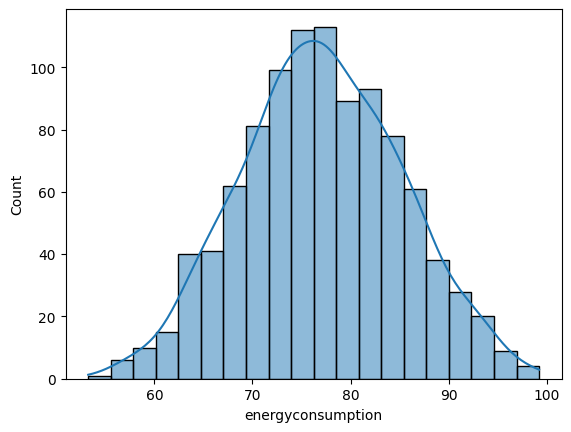

In [83]:
sns.histplot(data=df,x='energyconsumption',bins=20,kde=True)

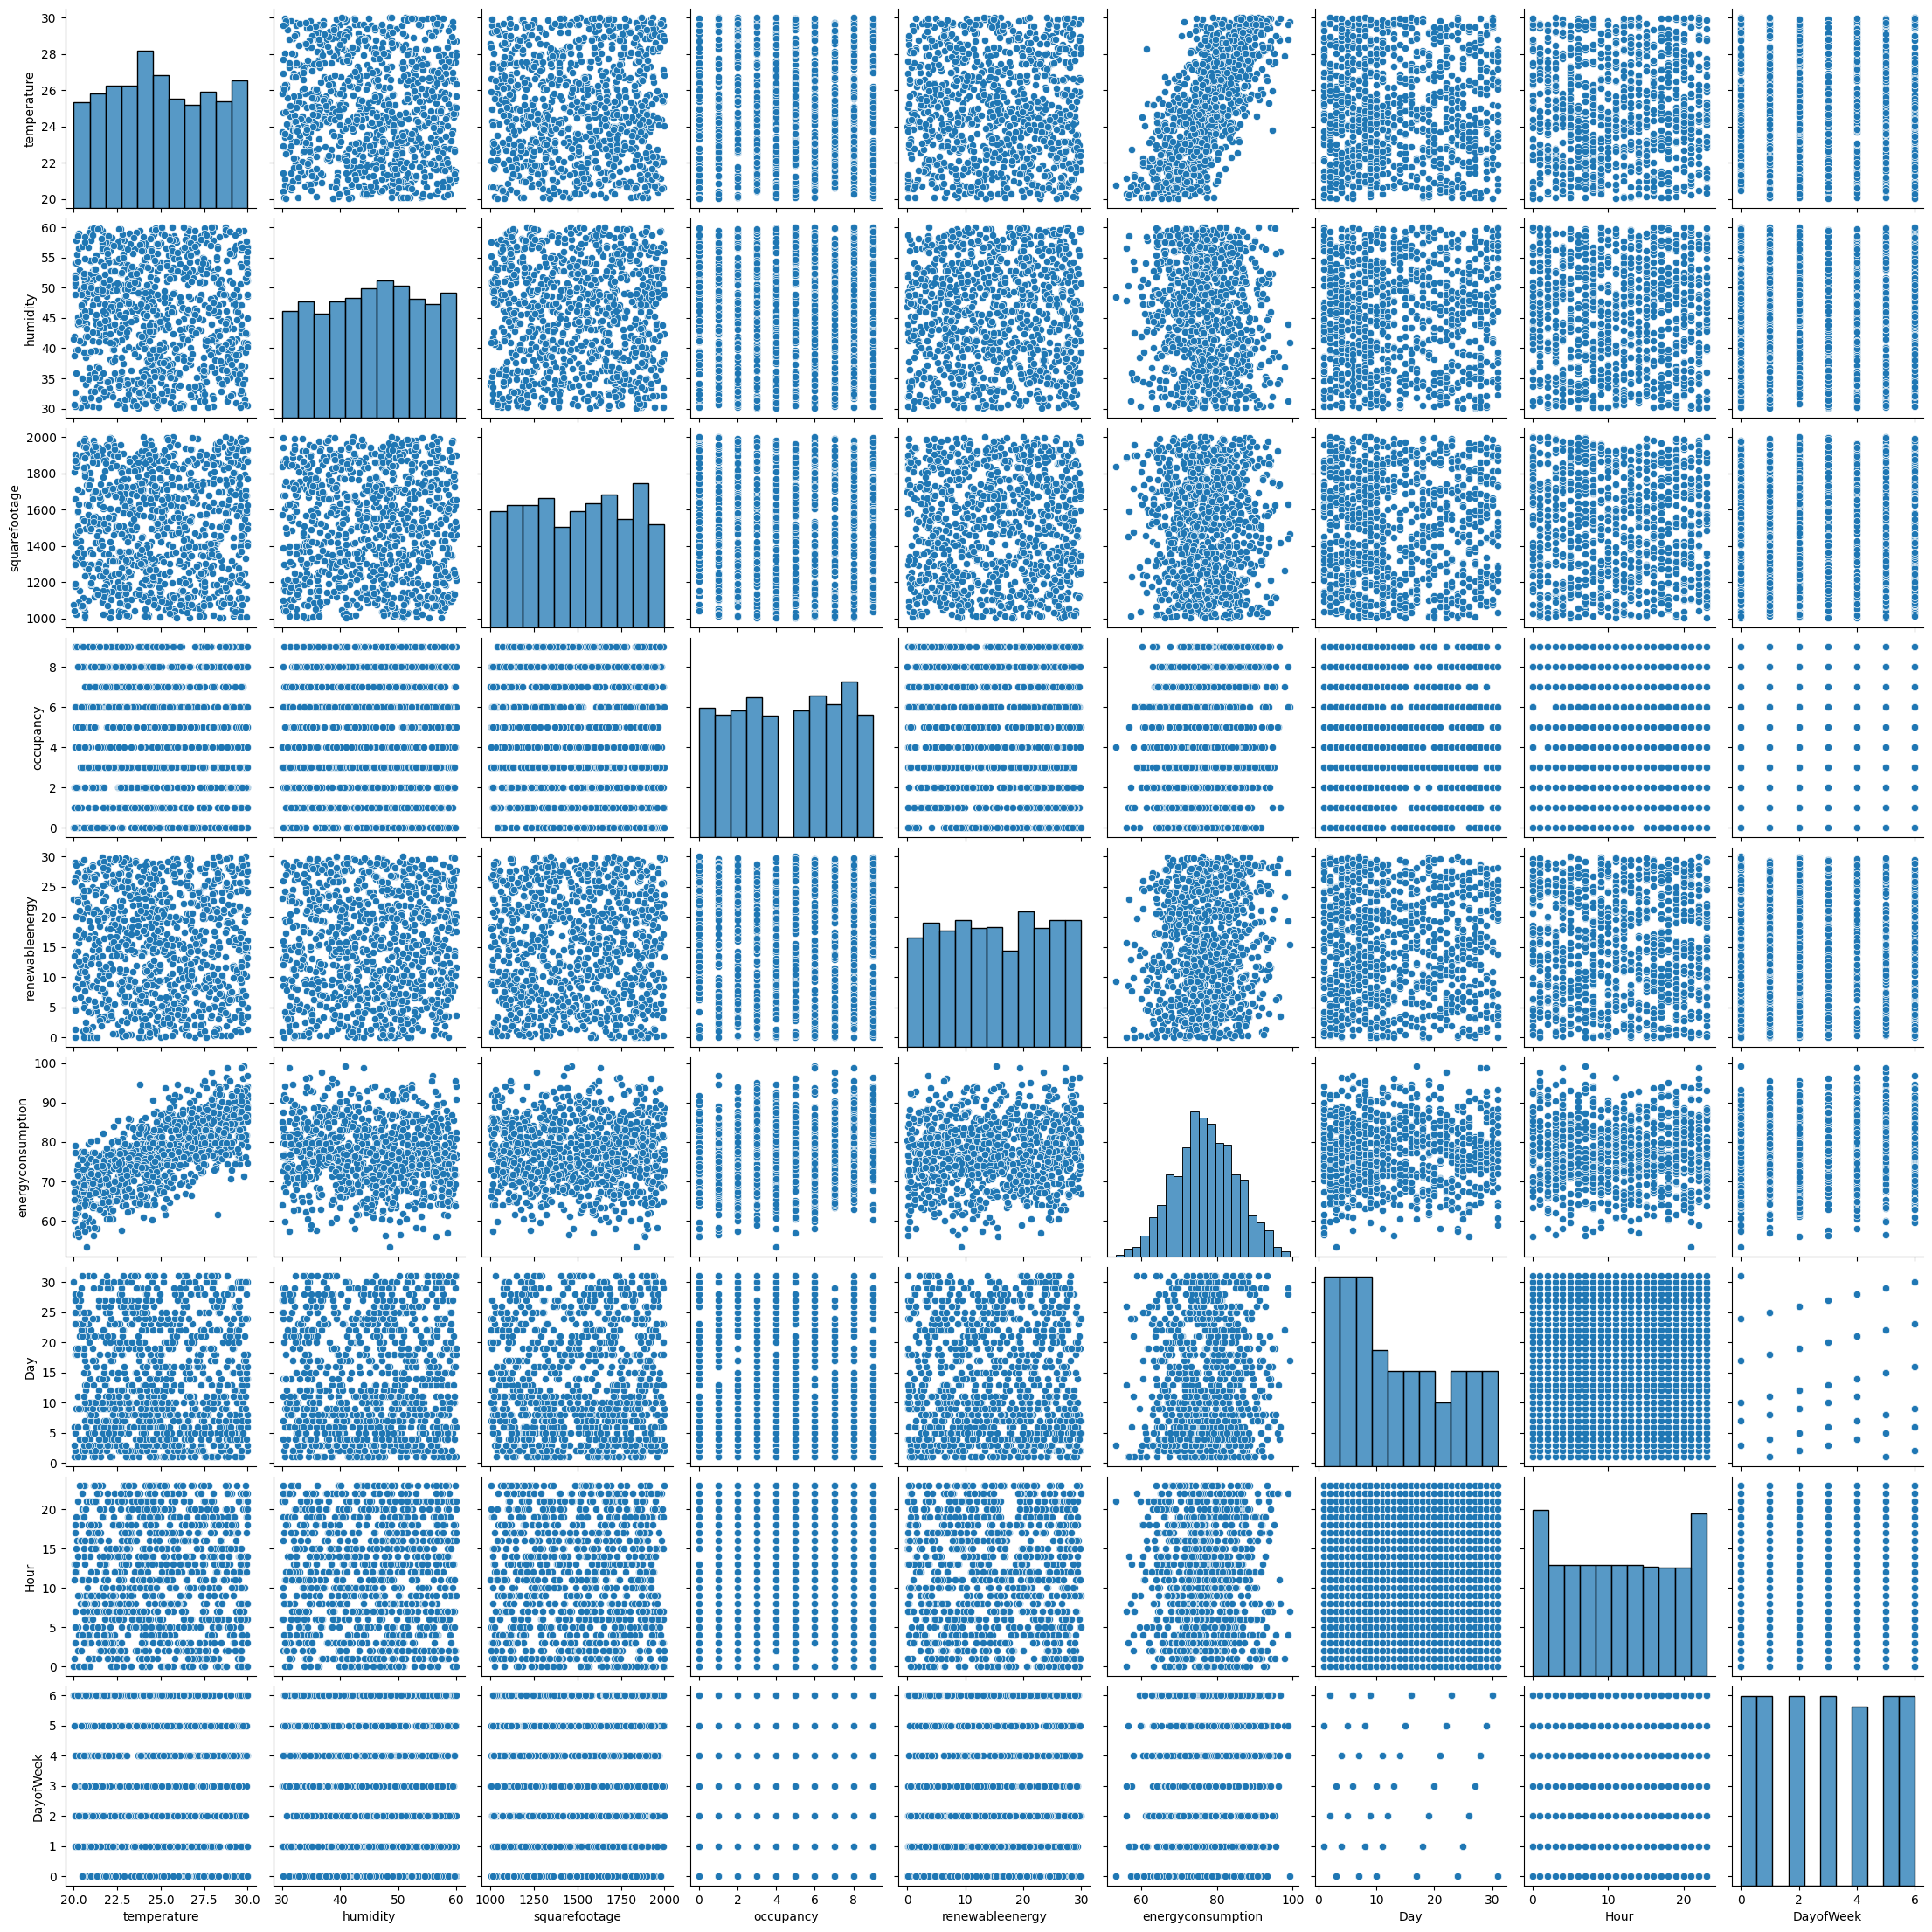

In [84]:
sns.pairplot(df)

<Axes: xlabel='humidity', ylabel='energyconsumption'>

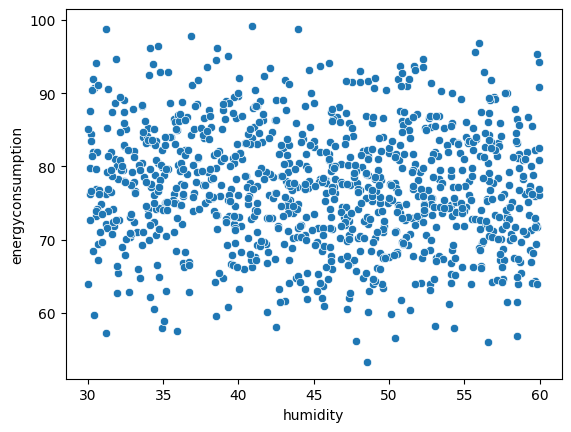

In [64]:
sns.scatterplot(data=df ,x=df['humidity'],y=df['energyconsumption'])

<Axes: xlabel='temperature', ylabel='energyconsumption'>

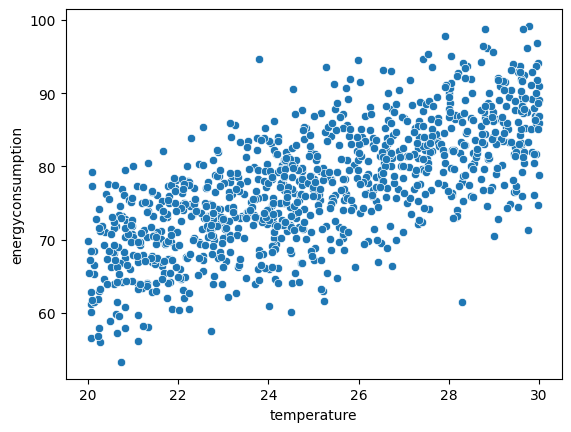

In [62]:
sns.scatterplot(data=df ,x=df['temperature'],y=df['energyconsumption'])

In [101]:
df

,timestamp,temperature,humidity,squarefootage,occupancy,hvacusage,lightingusage,renewableenergy,dayofweek,holiday,energyconsumption,Day,Hour,DayofWeek,DayName,week_of_year,quarter,is_weekend
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373,1,0,5,Saturday,52,1,False
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855,1,1,5,Saturday,52,1,False
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888,1,2,5,Saturday,52,1,False
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850,1,3,5,Saturday,52,1,False
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732,1,4,5,Saturday,52,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2022-02-11 11:00:00,28.619382,48.850160,1080.087000,5,Off,Off,21.194696,Saturday,No,82.306692,11,11,4,Friday,6,1,False
996,2022-02-11 12:00:00,23.836647,47.256435,1705.235156,4,Off,On,25.748176,Tuesday,Yes,66.577320,11,12,4,Friday,6,1,False
997,2022-02-11 13:00:00,23.005340,48.720501,1320.285281,6,Off,On,0.297079,Friday,Yes,72.753471,11,13,4,Friday,6,1,False
998,2022-02-11 14:00:00,25.138365,31.306459,1309.079719,3,On,Off,20.425163,Thursday,Yes,76.950389,11,14,4,Friday,6,1,False
